In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [2]:
from pathlib import Path
DATA = Path("/content/drive/MyDrive/dirisa-sdc/processed")
print(sorted(f.name for f in DATA.iterdir()))

['charts', 'clean_census_population.csv', 'clean_district_youth_history.csv', 'clean_master_municipality.csv', 'clean_provincial_turnout_2021.csv', 'clean_youth_registration.csv', 'district_trend.csv', 'municipality_features.csv', 'municipality_widest_gap.csv', 'priority_municipalities.csv']


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

DATA = Path("/content/drive/MyDrive/dirisa-sdc/processed")
CHARTS = DATA / "charts"
CHARTS.mkdir(parents=True, exist_ok=True)

In [5]:
df = pd.read_csv(DATA / "municipality_features.csv")

print("Shape:", df.shape)
print("\nAvailable columns:")
for c in df.columns:
    print("  ", c)

Shape: (33, 30)

Available columns:
   mdb_code
   municipality
   district
   total_pop_2022
   youth_pop_20_34_2022
   youth_share_pct_2022
   registered_2016
   valid_votes_2016
   spoilt_votes_2016
   votes_cast_2016
   turnout_pct_2016
   spoilt_rate_pct_2016
   registered_2021
   valid_votes_2021
   spoilt_votes_2021
   votes_cast_2021
   turnout_pct_2021
   spoilt_rate_pct_2021
   registered_growth_2016_2021_pct
   turnout_change_2016_2021_pp
   registered_youth_total
   youth_gap_2026
   youth_registration_rate_2026
   district_normalised
   district_municipality
   youth_registration_change_pct
   trend_rank
   gap_norm
   trend_norm
   youth_disengagement_risk


In [6]:
# Select features for clustering
feature_cols = [
    "youth_gap_2026",
    "youth_registration_rate_2026",
    "youth_registration_change_pct",
    "turnout_change_2016_2021_pp",
    "registered_growth_2016_2021_pct",
]

X = df[feature_cols].copy()

missing = X.isna().any(axis=1)
print(f"Rows with missing features: {missing.sum()}")
print(df.loc[missing, ["mdb_code", "municipality"]])

X_clean = X.dropna()
df_clean = df.loc[X_clean.index].copy()

print(f"\nUsable rows for clustering: {len(X_clean)}")

Rows with missing features: 9
   mdb_code               municipality
11    EC157     King Sabata Dalindyebo
15    EC441                  Matatiele
17    EC156                   Mhlontlo
20      NMA         Nelson Mandela Bay
23    EC444                 Ntabankulu
24    EC155                   Nyandeni
25    EC154              Port St Johns
30    EC442                  Umzimvubu
32    EC443  Winnie Madikizela-Mandela

Usable rows for clustering: 24


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

print("Mean after scaling:", X_scaled.mean(axis=0).round(3))
print("Std after scaling: ", X_scaled.std(axis=0).round(3))

Mean after scaling: [ 0. -0.  0. -0. -0.]
Std after scaling:  [1. 1. 1. 1. 1.]


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 8)
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))
    print(f"k={k}  silhouette={sil_scores[-1]:.3f}")

best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"\nBest k by silhouette: {best_k}")

k=2  silhouette=0.356
k=3  silhouette=0.380
k=4  silhouette=0.371
k=5  silhouette=0.414
k=6  silhouette=0.388
k=7  silhouette=0.355

Best k by silhouette: 5


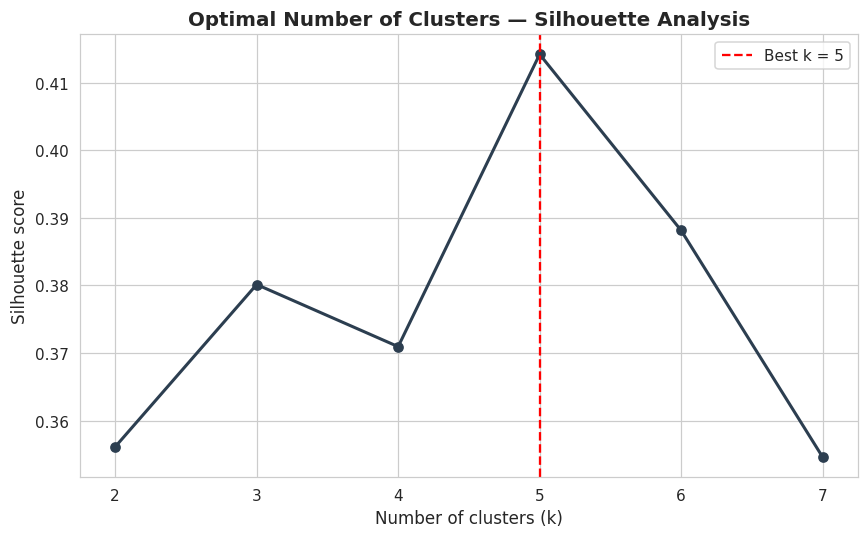

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), sil_scores, marker="o", color="#2c3e50", linewidth=2)
ax.axvline(best_k, color="red", linestyle="--", label=f"Best k = {best_k}")
ax.set_xlabel("Number of clusters (k)", fontsize=11)
ax.set_ylabel("Silhouette score", fontsize=11)
ax.set_title("Optimal Number of Clusters — Silhouette Analysis",
             fontsize=13, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig(CHARTS / "07_silhouette.png", bbox_inches="tight")
plt.show()

In [10]:
K_FINAL = 4

km = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df_clean["cluster"] = km.fit_predict(X_scaled)

print(f"Final silhouette (k={K_FINAL}): {silhouette_score(X_scaled, df_clean['cluster']):.3f}")
print("\nCluster sizes:")
print(df_clean["cluster"].value_counts().sort_index())

Final silhouette (k=4): 0.371

Cluster sizes:
cluster
0    11
1     7
2     5
3     1
Name: count, dtype: int64


In [11]:
profile = df_clean.groupby("cluster")[feature_cols].mean().round(3)

profile["n_municipalities"] = df_clean["cluster"].value_counts().sort_index()
profile["example_municipalities"] = df_clean.groupby("cluster")["municipality"].apply(
    lambda s: ", ".join(s.head(3))
)

print("Cluster profiles:")
print(profile.to_string())

Cluster profiles:
         youth_gap_2026  youth_registration_rate_2026  youth_registration_change_pct  turnout_change_2016_2021_pp  registered_growth_2016_2021_pct  n_municipalities                     example_municipalities
cluster                                                                                                                                                                                                        
0                 0.009                         1.080                        -10.177                       -7.042                           -2.681                11             Emalahleni, Engcobo, Great Kei
1                 0.218                         0.782                        -10.001                       -8.553                           -4.297                 7          Amahlathi, Buffalo City, Elundini
2                 0.262                         0.738                        -11.027                      -10.436                           -3.556    

In [12]:
def name_cluster(row):
    high_gap = row["youth_gap_2026"] > df_clean["youth_gap_2026"].median()
    widening = row["youth_registration_change_pct"] < df_clean["youth_registration_change_pct"].median()
    if high_gap and widening:
        return "High gap / Widening"
    elif high_gap and not widening:
        return "High gap / Stable"
    elif not high_gap and widening:
        return "Low gap / Widening"
    else:
        return "Low gap / Stable"

profile["cluster_name"] = profile.apply(name_cluster, axis=1)
df_clean["cluster_name"] = df_clean["cluster"].map(profile["cluster_name"])

print("Cluster names:")
for cid, row in profile.iterrows():
    print(f"  Cluster {cid}: {row['cluster_name']}  (n={row['n_municipalities']})")

Cluster names:
  Cluster 0: Low gap / Widening  (n=11)
  Cluster 1: High gap / Stable  (n=7)
  Cluster 2: High gap / Widening  (n=5)
  Cluster 3: High gap / Stable  (n=1)


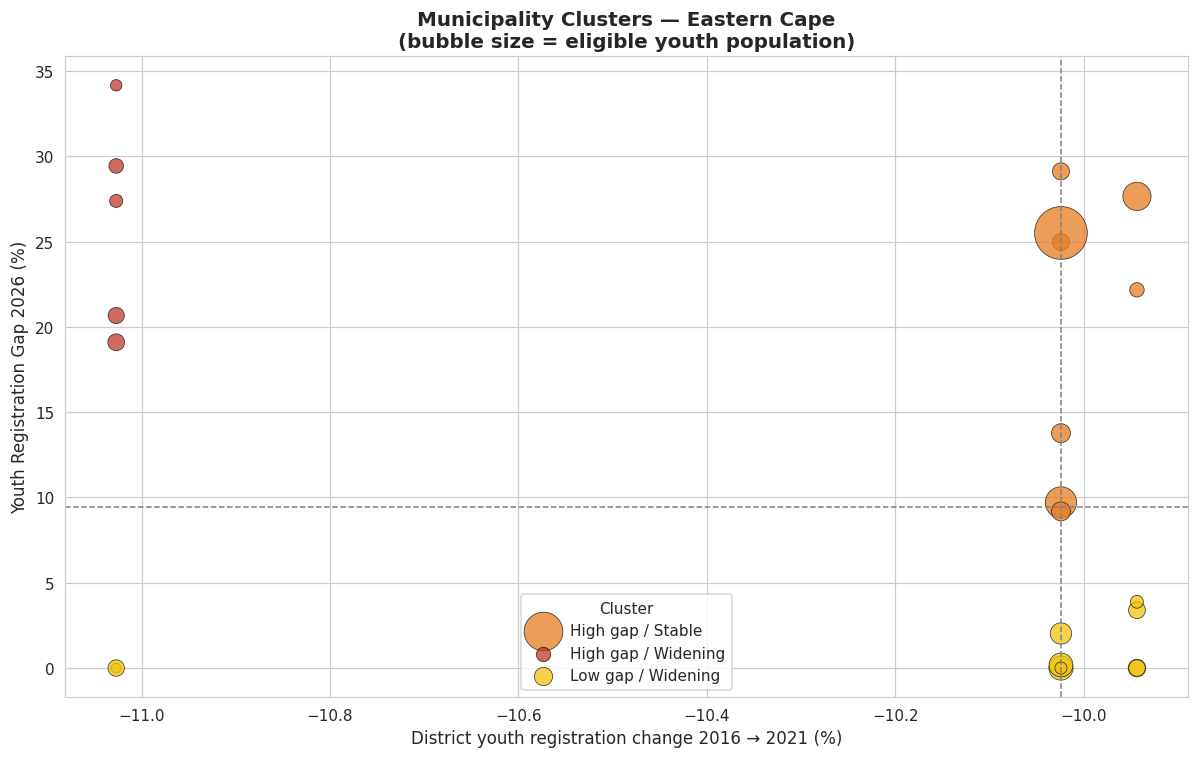

In [13]:
fig, ax = plt.subplots(figsize=(11, 7))

palette = {"High gap / Widening": "#c0392b",
           "High gap / Stable":   "#e67e22",
           "Low gap / Widening":   "#f1c40f",
           "Low gap / Stable":     "#27ae60"}

for name, group in df_clean.groupby("cluster_name"):
    ax.scatter(
        group["youth_registration_change_pct"],
        group["youth_gap_2026"] * 100,
        s=group["youth_pop_20_34_2022"] / 200,
        label=name,
        color=palette.get(name, "grey"),
        alpha=0.75,
        edgecolors="black",
        linewidth=0.5
    )

ax.set_xlabel("District youth registration change 2016 → 2021 (%)", fontsize=11)
ax.set_ylabel("Youth Registration Gap 2026 (%)", fontsize=11)
ax.set_title("Municipality Clusters — Eastern Cape\n(bubble size = eligible youth population)",
             fontsize=13, fontweight="bold")
ax.legend(title="Cluster")
ax.axvline(df_clean["youth_registration_change_pct"].median(), color="grey", linestyle="--", linewidth=1)
ax.axhline(df_clean["youth_gap_2026"].median() * 100, color="grey", linestyle="--", linewidth=1)

plt.tight_layout()
plt.savefig(CHARTS / "08_clusters.png", bbox_inches="tight")
plt.show()

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

reg_features = [
    "turnout_change_2016_2021_pp",
    "registered_growth_2016_2021_pct",
    "youth_share_pct_2022",
]

reg_data = df_clean.dropna(subset=reg_features + ["youth_gap_2026"])

X_reg = reg_data[reg_features]
y_reg = reg_data["youth_gap_2026"]

model = LinearRegression()
model.fit(X_reg, y_reg)

print("Regression: youth_gap_2026 ~ features")
print("Intercept:", round(model.intercept_, 4))
for name, coef in zip(reg_features, model.coef_):
    print(f"  {name:45s} {coef:+.4f}")

r2 = cross_val_score(model, X_reg, y_reg, cv=5, scoring="r2").mean()
print(f"\nCross-validated R²: {r2:.3f}")

Regression: youth_gap_2026 ~ features
Intercept: -0.6046
  turnout_change_2016_2021_pp                   -0.0069
  registered_growth_2016_2021_pct               +0.0009
  youth_share_pct_2022                          +0.0309

Cross-validated R²: -2.213


In [15]:
df_clean[[
    "mdb_code", "municipality", "district",
    "cluster", "cluster_name",
    "youth_gap_2026", "youth_registration_rate_2026",
    "youth_registration_change_pct",
    "youth_disengagement_risk"
]].to_csv(DATA / "municipality_clusters.csv", index=False)

print("Saved municipality_clusters.csv")
print("\nCluster summary:")
print(df_clean.groupby("cluster_name").size())

Saved municipality_clusters.csv

Cluster summary:
cluster_name
High gap / Stable       8
High gap / Widening     5
Low gap / Widening     11
dtype: int64


In [16]:
print("=" * 60)
print("MODEL SUMMARY")
print("=" * 60)
print(f"Municipalities clustered: {len(df_clean)}")
print(f"Clusters: {K_FINAL}")
print(f"Best k by silhouette: {best_k}")
print(f"Final silhouette (k=4): {silhouette_score(X_scaled, df_clean['cluster']):.3f}")
print(f"Regression CV R²: {r2:.3f}")
print()
print("Priority municipalities and their clusters:")
priority_df = pd.read_csv(DATA / "priority_municipalities.csv")
merged_priority = priority_df.merge(
    df_clean[["mdb_code", "cluster_name"]], on="mdb_code", how="left"
)
print(merged_priority[["priority_rank", "municipality", "cluster_name"]].head(15).to_string(index=False))

MODEL SUMMARY
Municipalities clustered: 24
Clusters: 4
Best k by silhouette: 5
Final silhouette (k=4): 0.371
Regression CV R²: -2.213

Priority municipalities and their clusters:
 priority_rank              municipality        cluster_name
             1             Enoch Mgijima   High gap / Stable
             2             Walter Sisulu   High gap / Stable
             3              Buffalo City   High gap / Stable
             4                 Amahlathi   High gap / Stable
             5           Inxuba Yethemba   High gap / Stable
             6        Nelson Mandela Bay                 NaN
             7                  Elundini   High gap / Stable
             8          Blue Crane Route High gap / Widening
             9               Ngquza Hill   High gap / Stable
            10                     Senqu   High gap / Stable
            11                   Ndlambe High gap / Widening
            12 Winnie Madikizela-Mandela                 NaN
            13      Sundays 

In [17]:
# Fallback cluster name for municipalities with missing data
df_clean_full = df.copy()
df_clean_full = df_clean_full.merge(
    df_clean[["mdb_code", "cluster_name"]], on="mdb_code", how="left"
)
df_clean_full["cluster_name"] = df_clean_full["cluster_name"].fillna("Insufficient data")

# Save full version
df_clean_full[[
    "mdb_code", "municipality", "district", "cluster_name",
    "youth_gap_2026", "youth_registration_rate_2026",
    "youth_registration_change_pct", "youth_disengagement_risk"
]].to_csv(DATA / "municipality_clusters_full.csv", index=False)

print("Saved municipality_clusters_full.csv")
print(df_clean_full["cluster_name"].value_counts())

Saved municipality_clusters_full.csv
cluster_name
Low gap / Widening     11
Insufficient data       9
High gap / Stable       8
High gap / Widening     5
Name: count, dtype: int64
